<a href="https://colab.research.google.com/github/sunitha-18577/skills-github-pages/blob/main/Cars24_prediction_my_Final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aim of the Project**

# We aim to analyze the growth and market dominance of major players in the used-car resale market (e.g., Cars24, CarWale, Spinny) using Regression model and eventually move toward predictive modeling. The goal is to understand trends in pricing, brand influence, and customer behavior to support investment or operational decisions.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


Load and undderstand the data

 Original data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               6437 non-null   object
 1   make               6437 non-null   object
 2   model              6437 non-null   object
 3   city               6437 non-null   object
 4   year               6437 non-null   int64 
 5   fueltype           6437 non-null   object
 6   kilometerdriven    6437 non-null   int64 
 7   ownernumber        6437 non-null   int64 
 8   transmission       6061 non-null   object
 9   bodytype           6062 non-null   object
 10  storename          6437 non-null   object
 11  isc24assured       6437 non-null   bool  
 12  registrationcity   6437 non-null   object
 13  registrationstate  6437 non-null   object
 14  benefits           6437 non-null   int64 
 15  discountprice      6437 non-null   int64 
 

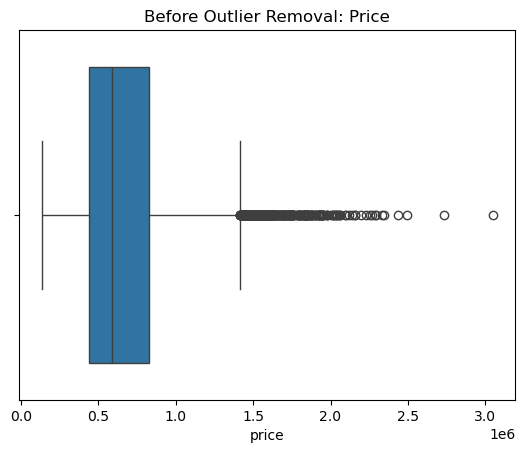

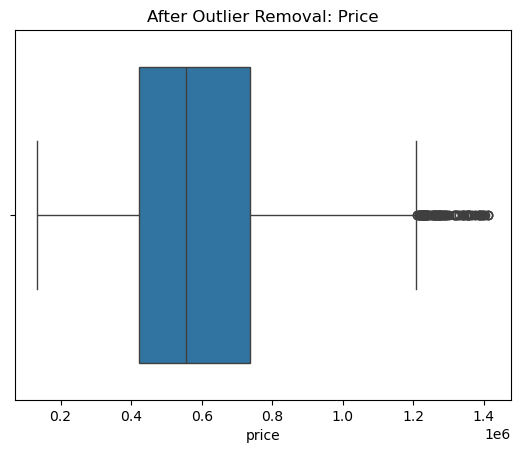

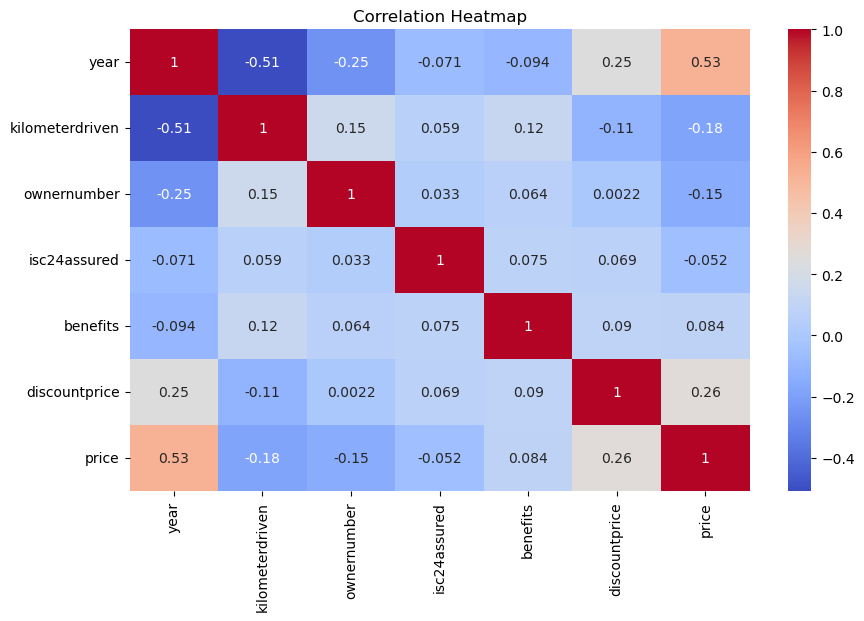

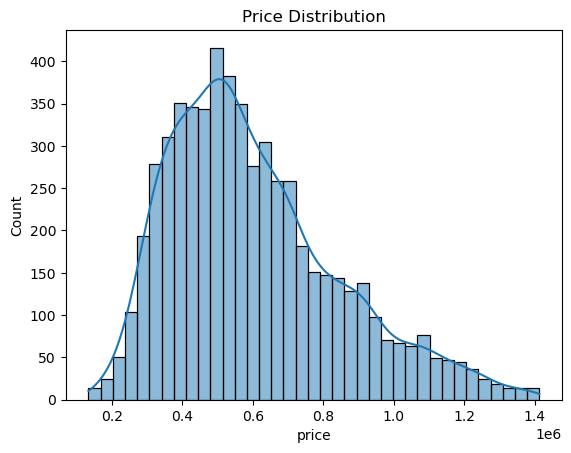

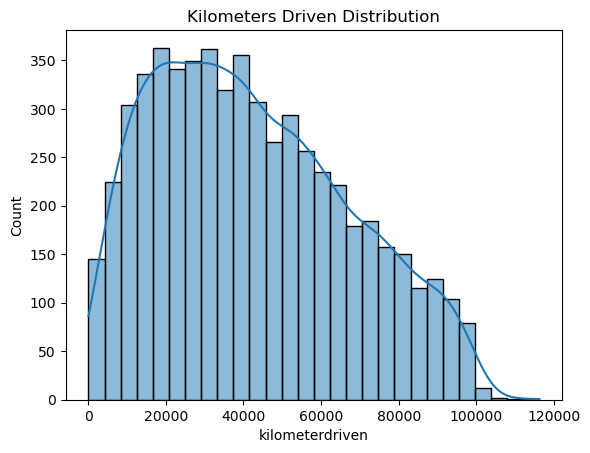

Linear Regression:
	MSE: 24046632701.37
	R2 Score:0.5908

Random Forest:
	MSE: 1887612436.24
	R2 Score:0.9679

Gradient Boosting:
	MSE: 4039624138.69
	R2 Score:0.9313



In [ ]:
def Cars24_Prediction():
    try:

        # Load the dataset
        print("Load and undderstand the data")
        df_original = pd.read_csv("cars24_20221210.csv")

        # Make a copy to preserve original data
        print("\n Original data")
        df = df_original.copy()

        # Structure and data types
        df.info()
        # First few rows
        df.head()

        # Total missing values in each column
        print("\nTotal missing values in each column:",df.isnull().sum())

        # Stats summary
        df.describe()

        # Categorical columns
        categorical_cols = df.select_dtypes(include='object').columns
        # Number of unique values
        df[categorical_cols].nunique().sort_values(ascending=False)

        # Check most common values in some key columns
        print("\n",df['fueltype'].value_counts())
        print("\n",df['transmission'].value_counts())
        print("\n",df['bodytype'].value_counts())

        # Fill missing 'transmission' and 'bodytype' with mode
        df['transmission'].fillna(df['transmission'].mode()[0], inplace=True)
        df['bodytype'].fillna(df['bodytype'].mode()[0], inplace=True)

        # These may not be useful for ML modeling
        df.drop(['url', 'createdDate', 'storename'], axis=1, inplace=True)

        # Replace negative discounts with 0 (if required)
        df['discountprice'] = df['discountprice'].apply(lambda x: x if x >= 0 else 0)

        # Function to remove outliers using IQR method
        def remove_outliers_iqr(df, column):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

        # Apply to relevant columns
        df = remove_outliers_iqr(df, 'kilometerdriven')
        df = remove_outliers_iqr(df, 'price')
        df = remove_outliers_iqr(df, 'discountprice')

        # Before removing outliers
        sns.boxplot(x=df_original['price'])
        plt.title("Before Outlier Removal: Price")
        plt.show()

        # After removing outliers
        sns.boxplot(x=df['price'])
        plt.title("After Outlier Removal: Price")
        plt.show()

        # Plot correlations
        plt.figure(figsize=(10, 6))
        sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
        plt.title("Correlation Heatmap")
        plt.show()

        # Distribution of price and kilometers driven
        sns.histplot(df['price'], kde=True)
        plt.title("Price Distribution")
        plt.show()

        sns.histplot(df['kilometerdriven'], kde=True)
        plt.title("Kilometers Driven Distribution")
        plt.show()

        #Feature Engineering
        #Car Age
        df['car_age'] = 2025 - df['year']

        #Price per km driven
        df['price_per_km'] = df['price'] / df['kilometerdriven']

        #First owner binary feature
        df['is_1st_owner'] = (df['ownernumber'] == 1).astype(int)

        #Transmission type binary
        df['is_automatic'] = (df['transmission'] == 'Automatic').astype(int)

        #Label encoding for objective column
        le = LabelEncoder()
        label_cols = ['name', 'make','model', 'city', 'fueltype','transmission','bodytype','registrationcity','registrationstate']
        for col in label_cols:
            df[col] = le.fit_transform(df[col])

        X = df.drop('price', axis=1)
        y = df['price']

        X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

        models= {
            'Linear Regression': LinearRegression(),
            'Random Forest': RandomForestRegressor(random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(random_state=42)
        }

        results ={}
        for name, model in models.items():
            model.fit(X_train,y_train)
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            r2 = r2_score(y_test,y_pred)
            results[name] = {'MSE':mse, "R2 Score":r2}

        for model, scores in results.items():
            print(f"{model}:\n\tMSE: {scores['MSE']:.2f}\n\tR2 Score:{scores['R2 Score']:.4f}\n")



    except FileNotFoundError:
        print("Error")


Cars24_Prediction()

In [ ]:
e